## Goal:

Train your first machine learning model to predict MPG.

What You'll Learn

By the end you'll understand:

Train/Test Split
Features (X)
Target (y)
Model Training
Predictions
Model Evaluation
Regression Metrics

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [21]:
df = pd.read_csv("../data/mpg_clean.csv")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,0,1


## Create Features and Target

In [22]:
# Target
y = df["mpg"]

# Features
X = df.drop("mpg", axis=1)

print(X.shape)
print(y.shape)

(392, 8)
(392,)


## Train/Test Split

In [23]:
# A model must be tested on data it has never seen.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print(X_train.shape)
print(y_train.shape)

(313, 8)
(313,)


## Create Model

In [25]:
model = LinearRegression()

## Train Model

In [26]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Make Predictions

In [29]:
predictions = model.predict(X_test)
predictions[:5]

array([26.62308629, 26.90246949, 34.26598184, 24.44117617, 28.23541424])

## Compare Actual vs Predicted

In [30]:
comparison = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : predictions
})

comparison.head(10)

,Actual,Predicted
78,26.0,26.623086
274,21.6,26.902469
246,36.1,34.265982
55,26.0,24.441176
387,27.0,28.235414
203,28.0,30.182539
42,13.0,8.561005
233,26.0,30.349163
150,19.0,20.381536
116,29.0,29.446287


## Evaluate Model

In [31]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 2.4619996980661427


In [32]:
rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("RMSE:", rmse)

RMSE: 3.256114096847396


In [33]:
r2 = r2_score(y_test, predictions)

print("R²:", r2)

R²: 0.7922774714022588


## Visualize Predictions

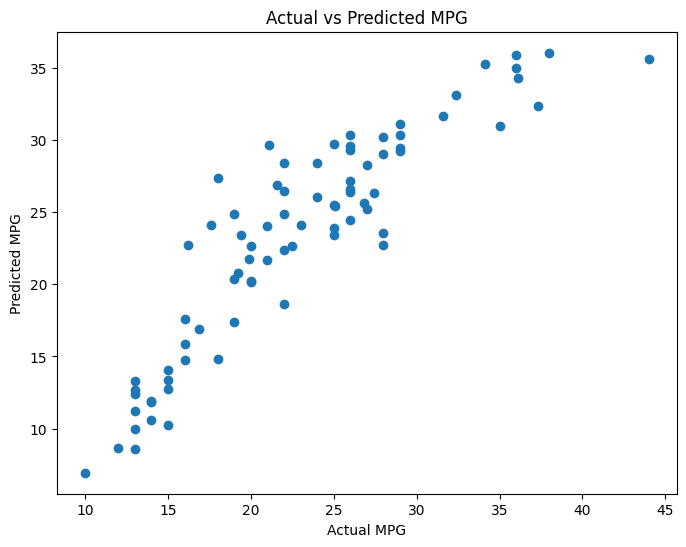

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

plt.show()

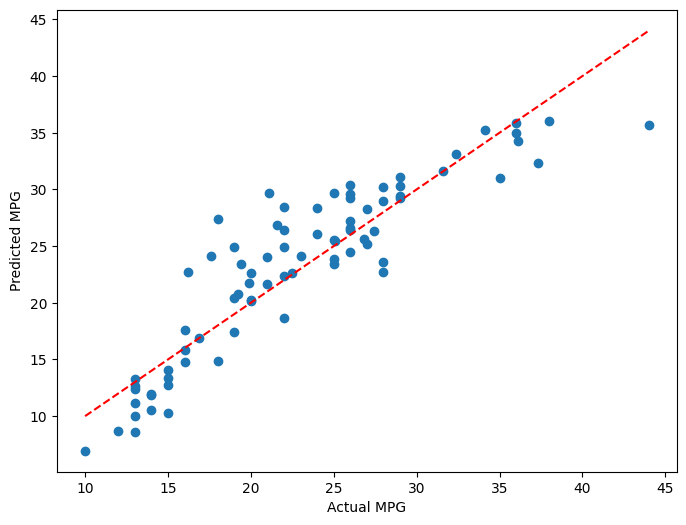

In [37]:
# Perfect predictions would lie on:
# y = x

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")

plt.show()

## Feature Importance

In [38]:
# Linear Regression coefficients:

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    "Coefficient",
    ascending=False
)

,Feature,Coefficient
5,model_year,0.797161
6,origin_japan,0.330470
4,acceleration,0.042198
1,displacement,0.019206
3,weight,-0.006423
2,horsepower,-0.021620
0,cylinders,-0.342101
7,origin_usa,-2.875499
